In [1]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np

In [4]:
wfst_version = "WFST_KN_170817A"
wfst_data_path = f'/fred/oz016/bgao_kn/SNANA/SNDATA_ROOT/SIM/{wfst_version}/'
head = wfst_data_path + f'{wfst_version}_HEAD.FITS'
phot = wfst_data_path + f'{wfst_version}_PHOT.FITS'

In [2]:
def convert_fluxcal_to_mag(flux, err):
    """Convert SNANA FLUXCAL to magnitude with error.

    Args:
        flux: Array of FLUXCAL values (zeropoint = 27.5)
        err: Array of FLUXCALERR values
    Returns:
        tuple: (magnitude, magnitude_error) arrays
    """
    flux = np.asarray(flux, dtype=float)
    flux[flux <= 0] = np.nan
    
    mag = -2.5 * np.log10(flux) + 27.5
    magerr = 2.5 / np.log(10) * err / flux
    return mag, magerr

# plot Light curve for specific SNID
def plot_lc_by_snid(snid, sim_version, survey='WFST'):
    """Plot light curve for a specific SNID.
    
    Args:
        snid: Target SNID to plot (string or int)
        sim_version: Simulation version name (e.g., 'WFST_KN_170817A')
        survey: Survey name ('WFST' or 'LSST')
    """
    # Construct data paths
    data_path = f'/fred/oz016/bgao_kn/SNANA/SNDATA_ROOT/SIM/{sim_version}/'
    head_file = data_path + f'{sim_version}_HEAD.FITS'
    phot_file = data_path + f'{sim_version}_PHOT.FITS'
    
    # Open PHOT and HEAD files
    phot_hdul = fits.open(phot_file)
    phot_data = phot_hdul[1].data
    head_hdul = fits.open(head_file)
    head_data = head_hdul[1].data
    
    # Convert snid to string and find the matching source
    snid_str = str(snid).strip()
    snid_found = False
    source_idx = None
    
    for i, file_snid in enumerate(head_data['SNID']):
        if file_snid.strip() == snid_str:
            source_idx = i
            snid_found = True
            break
    
    if not snid_found:
        print(f"Error: SNID {snid_str} not found in {sim_version}")
        return
    
    # Get observation range for this SNID
    start = head_data['PTROBS_MIN'][source_idx]
    end = head_data['PTROBS_MAX'][source_idx]
    
    # Define bands based on survey
    if survey.upper() == 'WFST':
        bands = ['WFST-u', 'WFST-g', 'WFST-r']
    elif survey.upper() == 'LSST':
        bands = ['LSST-u', 'LSST-g', 'LSST-r', 'LSST-i', 'LSST-z', 'LSST-Y']
    else:
        bands = ['WFST-u', 'WFST-g', 'WFST-r']
    
    # Extract source data
    source_data = phot_data[start-1:end]  # FITS index usually starts from 1
    peakmjd = head_data['PEAKMJD'][source_idx]
    
    print(f'Plotting SNID {snid_str}, PEAKMJD: {peakmjd:.2f}, Index range: {start}-{end}')
    
    # Calculate flux and magnitude
    mjd = source_data['MJD']
    flux = source_data['FLUXCAL']
    fluxerr = source_data['FLUXCALERR']
    snr = flux / fluxerr
    mask = snr < 3
    mag, magerr = convert_fluxcal_to_mag(flux=flux.copy(), err=fluxerr)
    mag[mask], magerr[mask] = np.nan, np.nan
    
    # Create figure
    plt.figure(figsize=(18, 6))
    
    # Subplot 1: Flux
    plt.subplot(121)
    plt.axvline(x=peakmjd, color='k', linestyle='--', label='PEAKMJD')
    for band in bands:
        band_mask = source_data['BAND'] == band
        if np.any(band_mask):
            plt.errorbar(mjd[band_mask], flux[band_mask], yerr=fluxerr[band_mask], 
                        fmt='o', label=band)
    plt.xlabel('MJD', fontsize=18)
    plt.xticks(fontsize=14)
    plt.ylabel('FLUXCAL', fontsize=18)
    plt.yticks(fontsize=14)
    plt.title(f'Light Curve - SNID {snid_str} (Flux)', fontsize=18)
    plt.legend(fontsize=12)
    
    # Subplot 2: Magnitude
    plt.subplot(122)
    plt.axvline(x=peakmjd, color='k', linestyle='--', label='PEAKMJD')
    for band in bands:
        band_mask = source_data['BAND'] == band
        if np.any(band_mask):
            plt.errorbar(mjd[band_mask], mag[band_mask], yerr=magerr[band_mask], 
                        fmt='o', label=band)
    plt.xlabel('MJD', fontsize=18)
    plt.xticks(fontsize=14)
    plt.ylabel('MAG', fontsize=18)
    plt.yticks(fontsize=14)
    plt.gca().invert_yaxis()
    plt.title(f'Light Curve - SNID {snid_str} (Magnitude)', fontsize=18)
    plt.legend(fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
    # Close FITS files
    phot_hdul.close()
    head_hdul.close()

Plotting source 1, PEAKMJD: 61362.4921875, Index range: 1-222
Plotting source 2, PEAKMJD: 61365.37890625, Index range: 224-403
Plotting source 3, PEAKMJD: 61536.12890625, Index range: 405-632
Plotting source 4, PEAKMJD: 61356.47265625, Index range: 634-1227
Plotting source 5, PEAKMJD: 61243.546875, Index range: 1229-1471


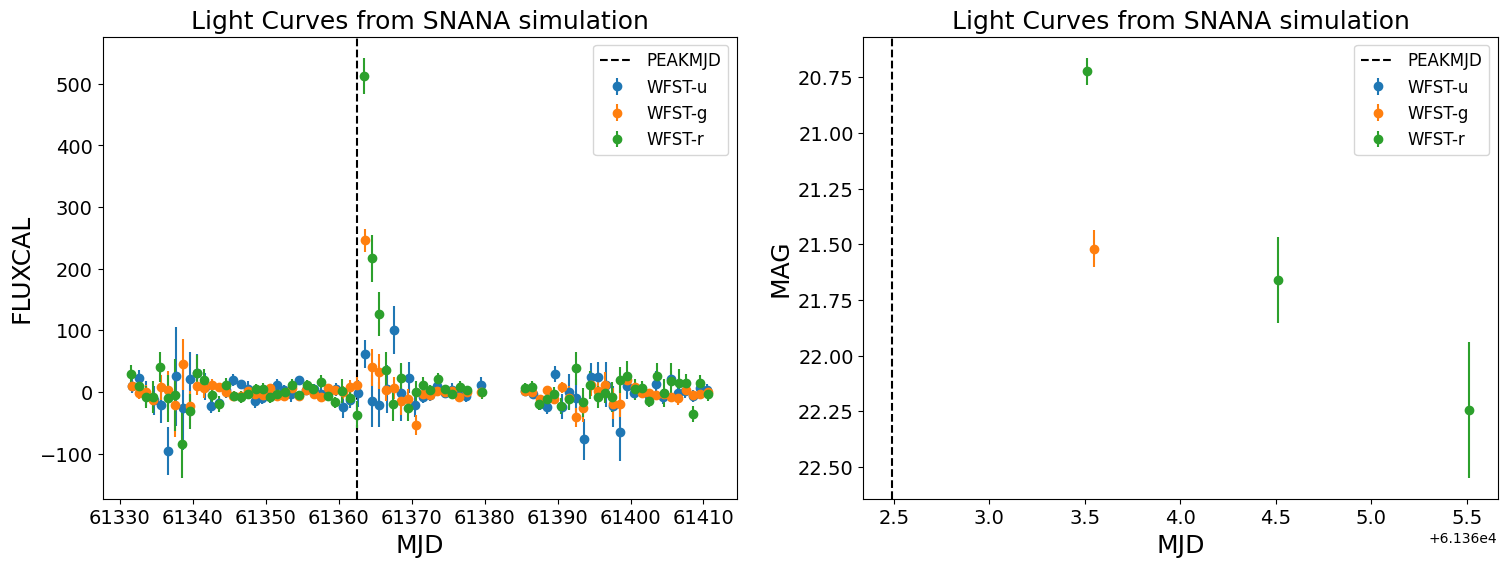

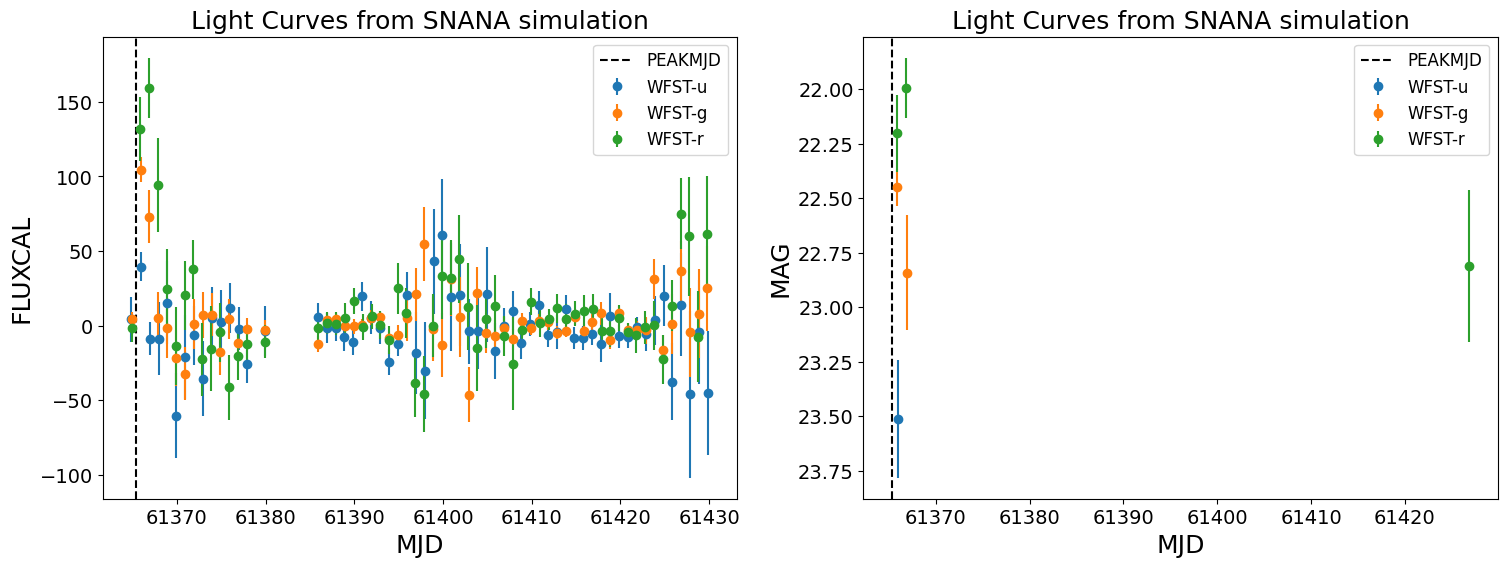

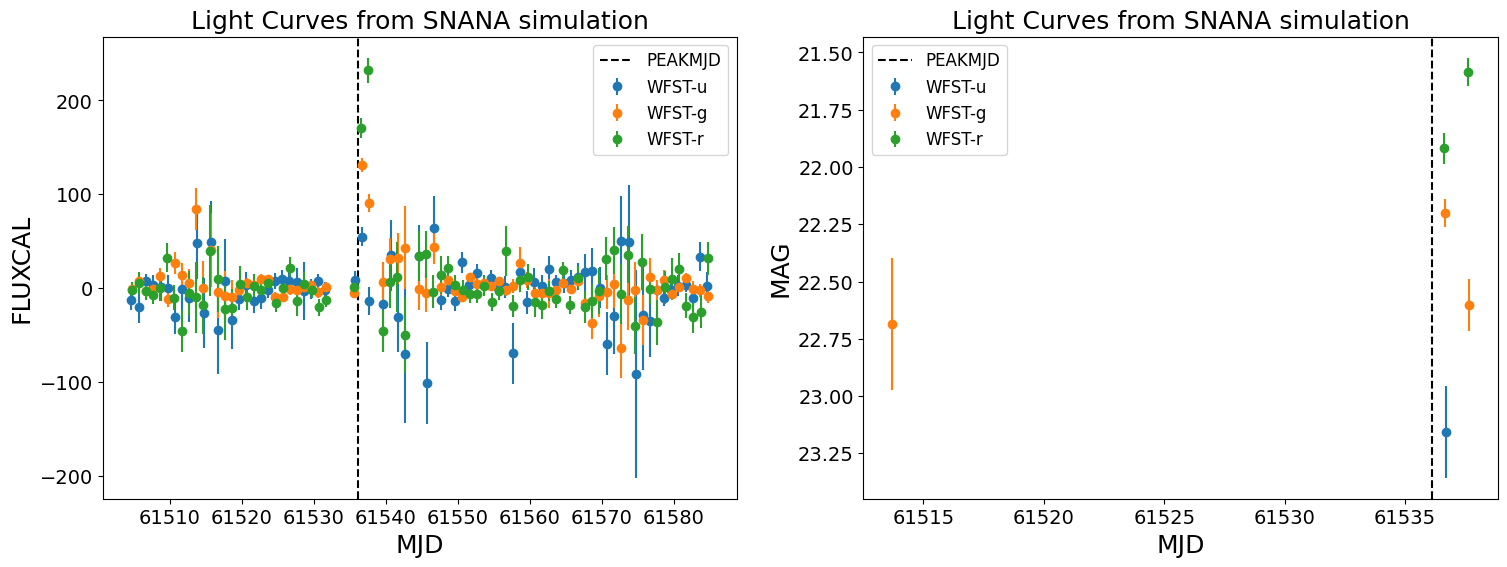

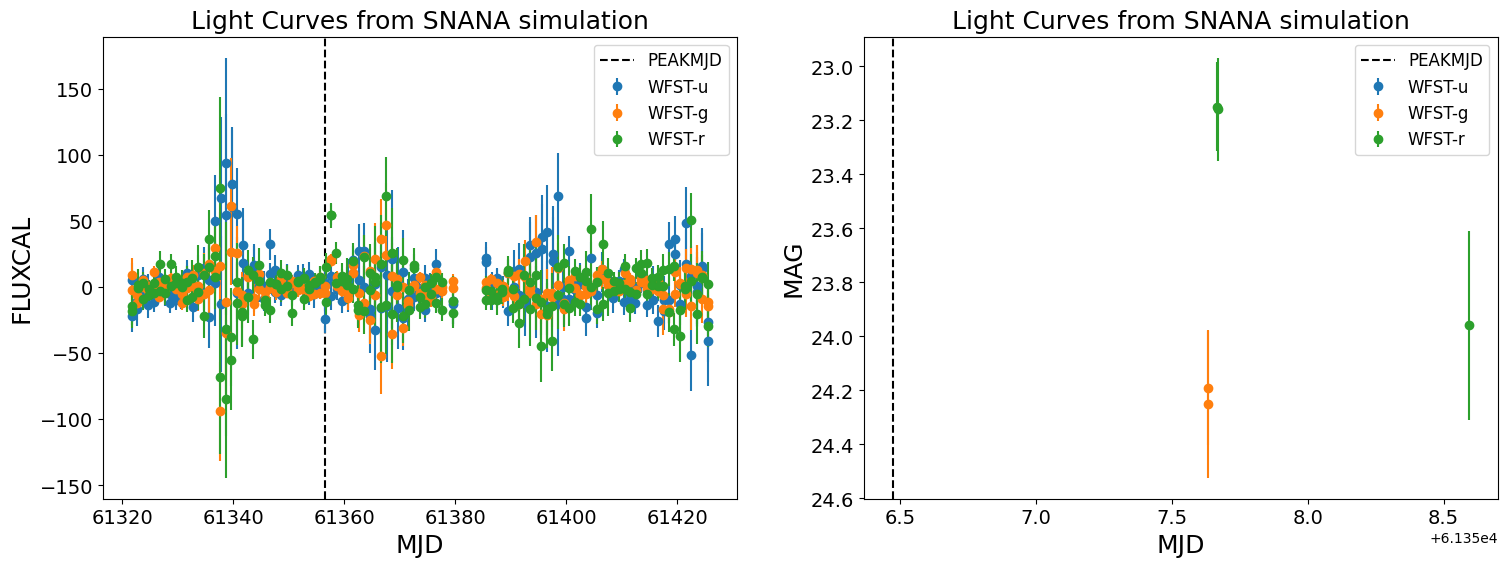

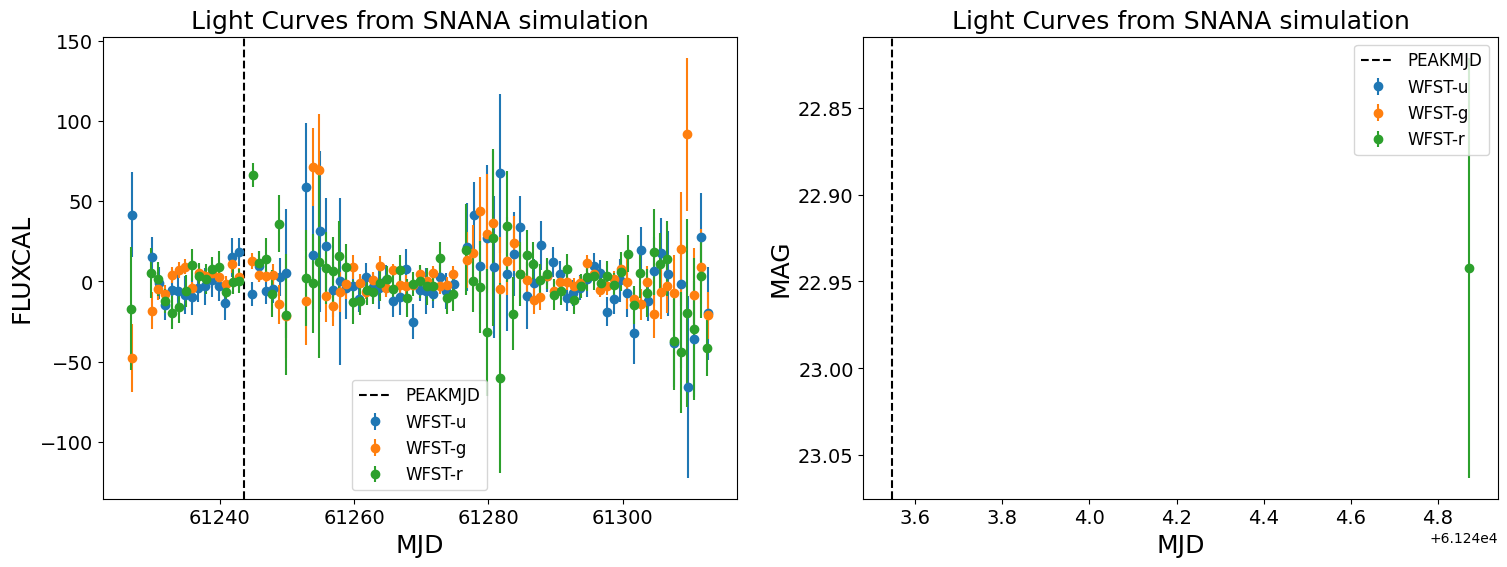

In [4]:
# 打开PHOT.fits文件
phot_hdul = fits.open(phot)
phot_data = phot_hdul[1].data

# 打开HEAD.fits文件，获取每个源的光变曲线索引分界
head_hdul = fits.open(head)
head_data = head_hdul[1].data
start_indices = head_data['PTROBS_MIN']
end_indices = head_data['PTROBS_MAX']

# 绘制每个源的光变曲线
bands = ['WFST-u','WFST-g','WFST-r']
for i, (start, end) in enumerate(zip(start_indices, end_indices)):
    if i >= 5:
        break
    plt.figure(figsize=(18, 6))
    # plt.gca().invert_yaxis()
    peakmjd = head_data['SIM_PEAKMJD'][i]
    #mjd_explode = head_data['SIM_MJD_EXPLODE'][i]
    print(f'Plotting source {i+1}, PEAKMJD: {peakmjd}, Index range: {start}-{end}')
    #plt.axvline(x=mjd_explode, color='r', linestyle='--', label="Merger MJD")
    source_data = phot_data[start-1:end]  # FITS索引通常从1开始
    mjd = source_data['MJD']
    flux = source_data['FLUXCAL']
    fluxerr = source_data['FLUXCALERR']
    snr = flux / fluxerr
    mask_det = snr > 5
    # if np.sum(mask_det) != 1:
    #     print("Number of detection:", np.sum(mask_det))
    #     continue
    mask = snr < 3
    mag, magerr = convert_fluxcal_to_mag(flux=flux.copy(), err=fluxerr)
    mag[mask], magerr[mask] = np.nan, np.nan
    plt.subplot(121)
    plt.axvline(x=peakmjd, color='k', linestyle='--', label='PEAKMJD')
    for band in bands:
        band_mask = source_data['BAND'] == band
        plt.errorbar(mjd[band_mask], flux[band_mask], yerr=fluxerr[band_mask], fmt='o', label=band)
        plt.xlabel('MJD', fontsize=18)
        plt.xticks(fontsize=14)
        plt.ylabel('FLUXCAL', fontsize=18)
        plt.yticks(fontsize=14)
        plt.title('Light Curves from SNANA simulation', fontsize=18)
        plt.legend(fontsize=12)
    plt.subplot(122)
    plt.axvline(x=peakmjd, color='k', linestyle='--', label='PEAKMJD')
    for band in bands:
        band_mask = source_data['BAND'] == band
        plt.errorbar(mjd[band_mask], mag[band_mask], yerr=magerr[band_mask], fmt='o', label=band)
        plt.xlabel('MJD', fontsize=18)
        plt.xticks(fontsize=14)
        plt.ylabel('MAG', fontsize=18)
        plt.yticks(fontsize=14)
        plt.gca().invert_yaxis()
        plt.title('Light Curves from SNANA simulation', fontsize=18)
        plt.legend(fontsize=12)
    
        #plt.savefig(f'/fred/oz016/bgao_kn/data/SNANA_SIM/lc_fig/KNLC_{i+1}.png')
# plt.show()

Plotting SNID 152, PEAKMJD: 61537.61, Index range: 6147-6377


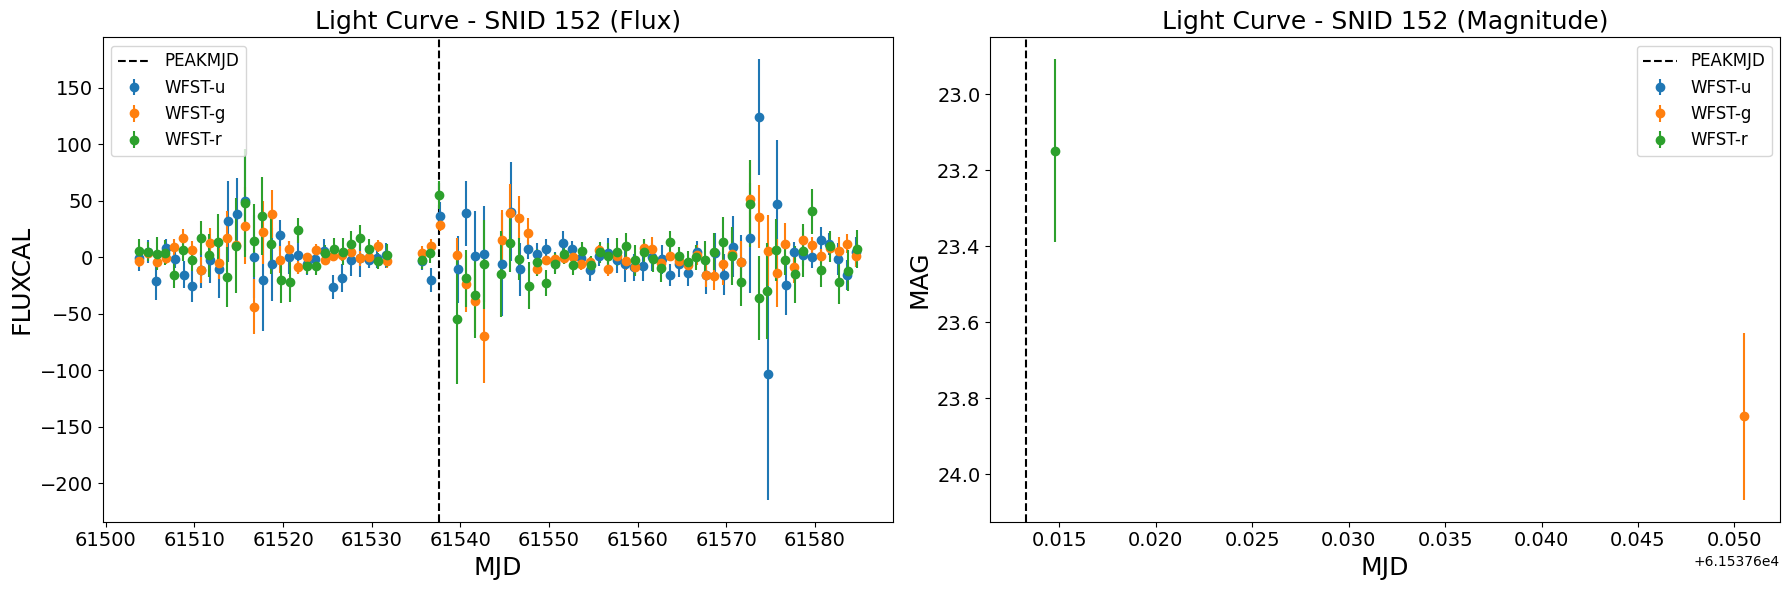

In [3]:
# Example: Plot light curve for a specific SNID
plot_lc_by_snid(snid='152', sim_version='WFST_KN_170817A', survey='WFST')

In [ ]:
LSST_data_path = f'/fred/oz016/bgao_kn/SNANA/SNDATA_ROOT/SIM/LSST_KN/'
head = LSST_data_path + f'LSST_KN_HEAD.FITS'
phot = LSST_data_path + f'LSST_KN_PHOT.FITS'

Plotting source 1, PEAKMJD: 61362.4921875, Index range: 1-222
Plotting source 2, PEAKMJD: 61365.37890625, Index range: 224-403
Plotting source 3, PEAKMJD: 61536.12890625, Index range: 405-632
Plotting source 4, PEAKMJD: 61445.39453125, Index range: 634-927
Plotting source 5, PEAKMJD: 61476.25, Index range: 929-1213


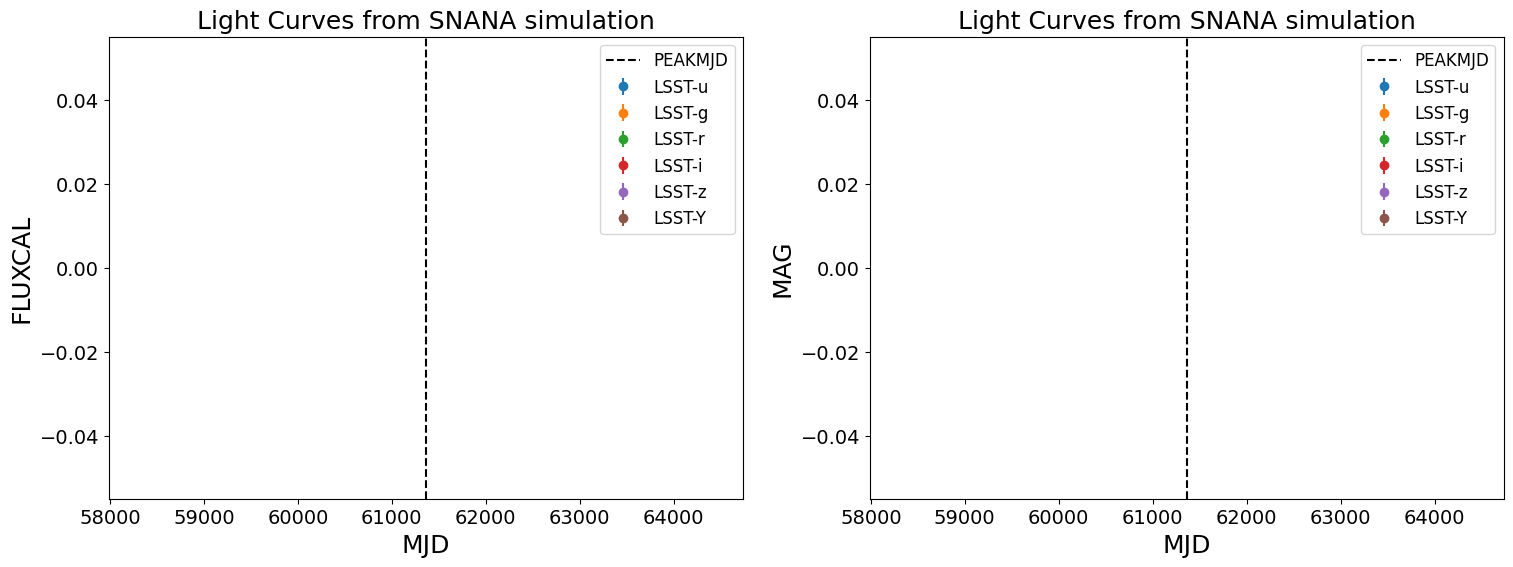

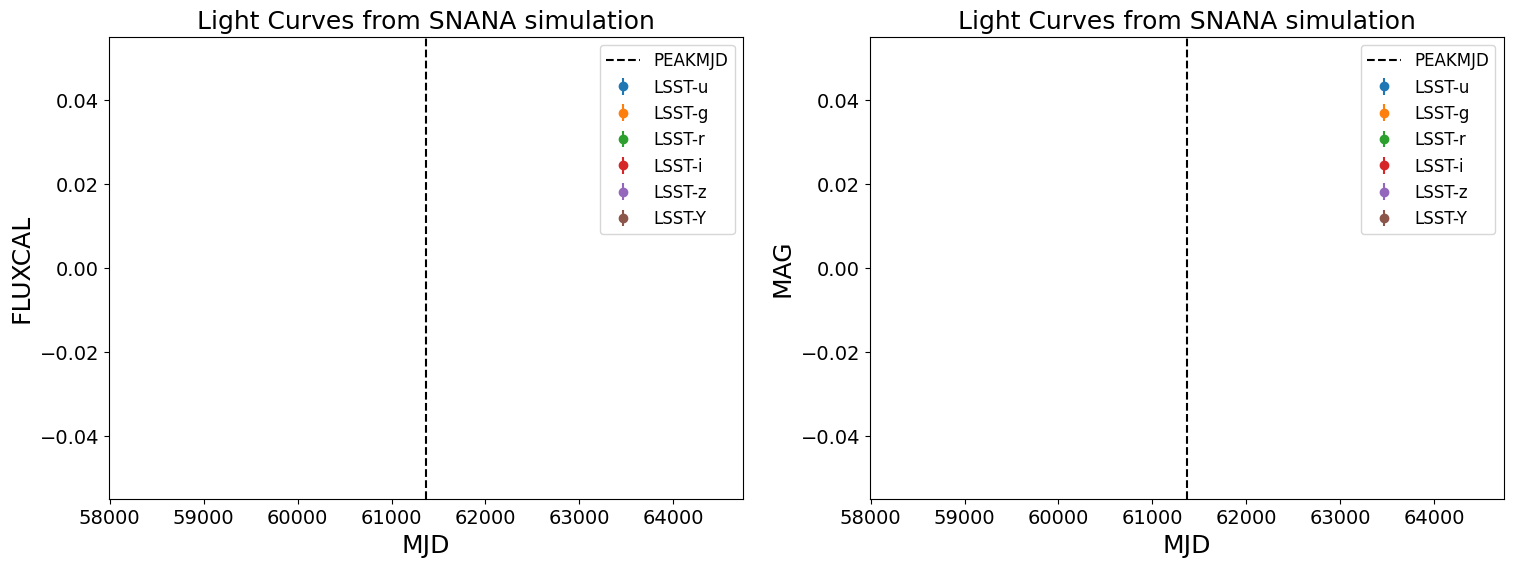

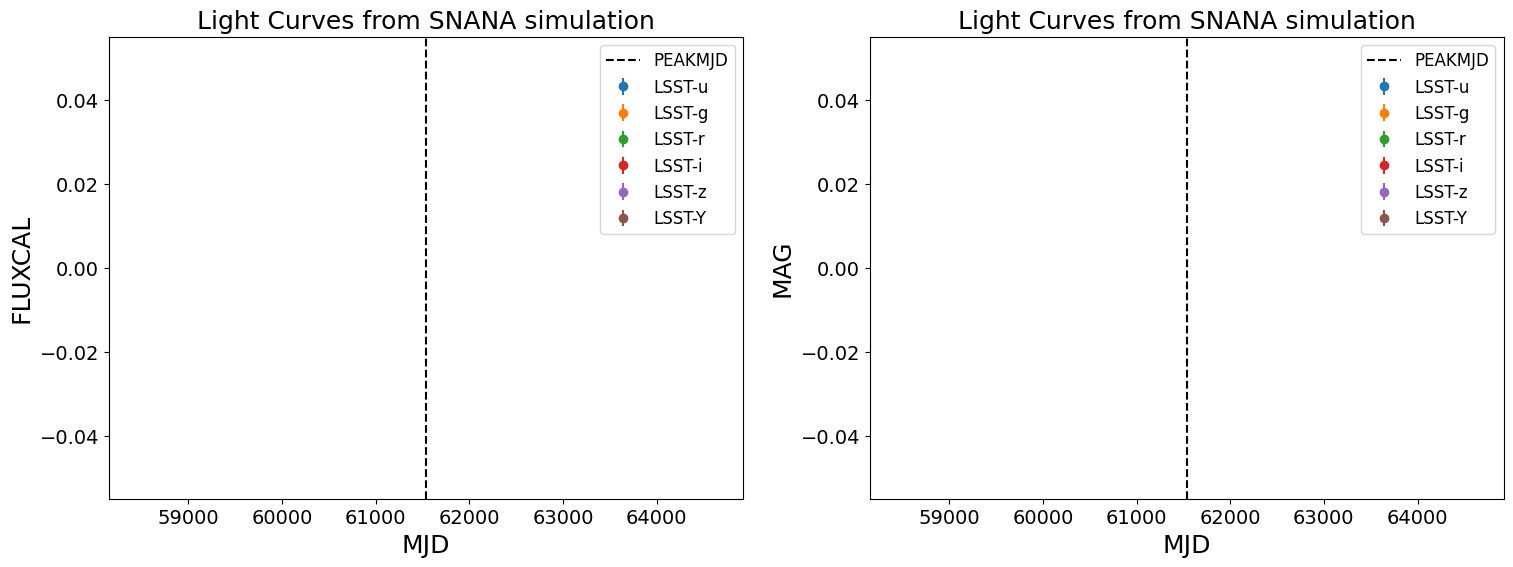

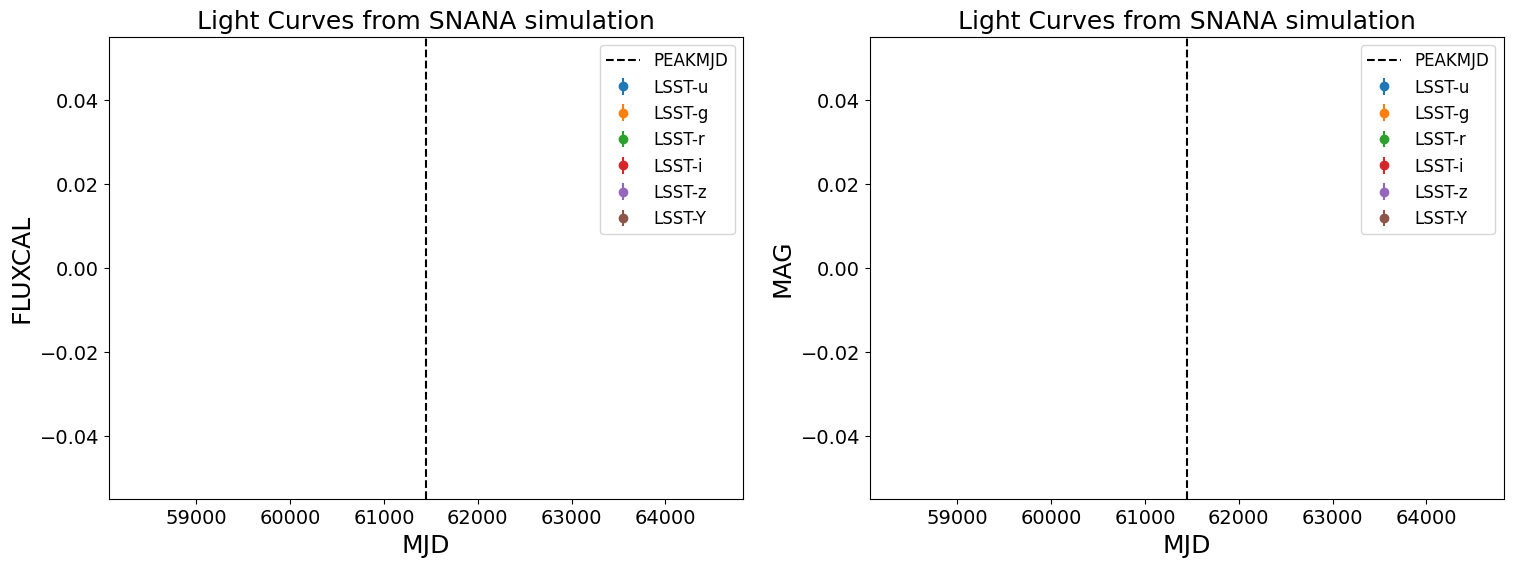

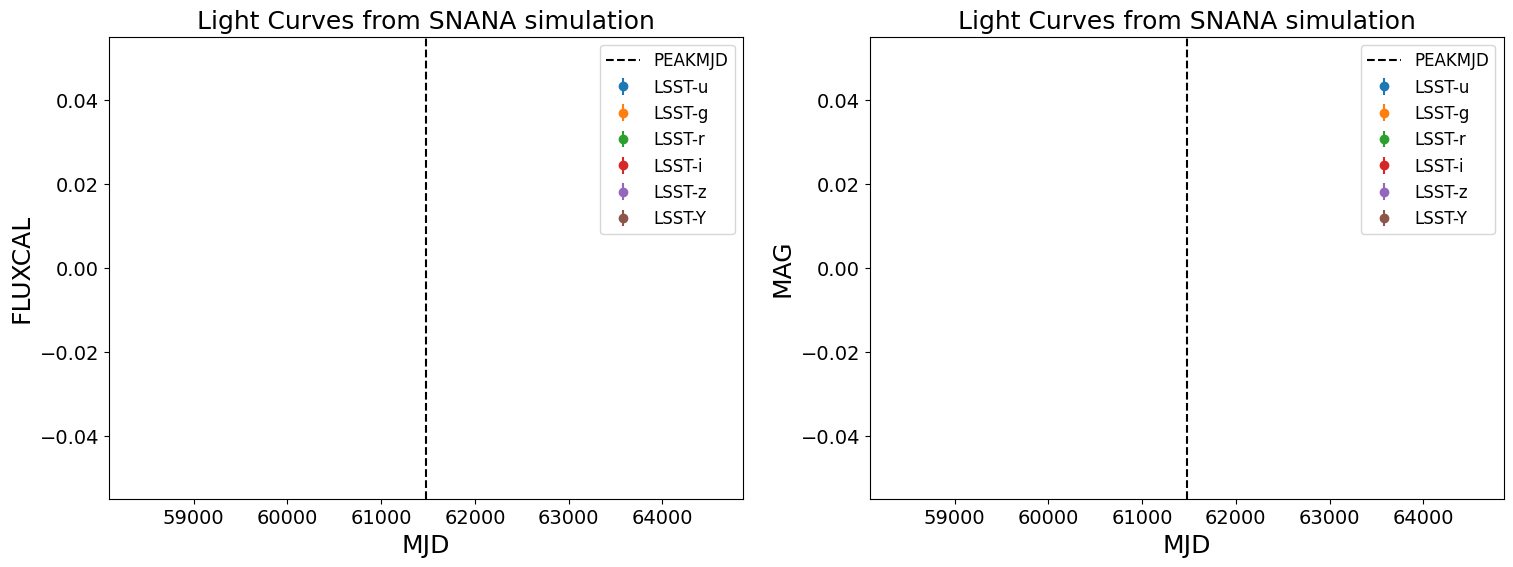

In [5]:
# 打开PHOT.fits文件
phot_hdul = fits.open(phot)
phot_data = phot_hdul[1].data

# 打开HEAD.fits文件，获取每个源的光变曲线索引分界
head_hdul = fits.open(head)
head_data = head_hdul[1].data
start_indices = head_data['PTROBS_MIN']
end_indices = head_data['PTROBS_MAX']

# 绘制每个源的光变曲线
bands = ['LSST-u','LSST-g','LSST-r','LSST-i','LSST-z','LSST-Y']
for i, (start, end) in enumerate(zip(start_indices, end_indices)):
    if i >=5:
        break
    plt.figure(figsize=(18, 6))
    # plt.gca().invert_yaxis()
    peakmjd = head_data['SIM_PEAKMJD'][i]
    #mjd_explode = head_data['SIM_MJD_EXPLODE'][i]
    print(f'Plotting source {i+1}, PEAKMJD: {peakmjd}, Index range: {start}-{end}')
    #plt.axvline(x=mjd_explode, color='r', linestyle='--', label="Merger MJD")
    source_data = phot_data[start-1:end]  # FITS索引通常从1开始
    mjd = source_data['MJD']
    flux = source_data['FLUXCAL']
    fluxerr = source_data['FLUXCALERR']
    snr = flux / fluxerr
    mask = snr < 3
    mag, magerr = convert_fluxcal_to_mag(flux=flux.copy(), err=fluxerr)
    mag[mask], magerr[mask] = np.nan, np.nan
    plt.subplot(121)
    plt.axvline(x=peakmjd, color='k', linestyle='--', label='PEAKMJD')
    for band in bands:
        band_mask = source_data['BAND'] == band
        plt.errorbar(mjd[band_mask], flux[band_mask], yerr=fluxerr[band_mask], fmt='o', label=band)
        plt.xlabel('MJD', fontsize=18)
        plt.xticks(fontsize=14)
        plt.ylabel('FLUXCAL', fontsize=18)
        plt.yticks(fontsize=14)
        plt.title('Light Curves from SNANA simulation', fontsize=18)
        plt.legend(fontsize=12)
    plt.subplot(122)
    plt.axvline(x=peakmjd, color='k', linestyle='--', label='PEAKMJD')
    for band in bands:
        band_mask = source_data['BAND'] == band
        plt.errorbar(mjd[band_mask], mag[band_mask], yerr=magerr[band_mask], fmt='o', label=band)
        plt.xlabel('MJD', fontsize=18)
        plt.xticks(fontsize=14)
        plt.ylabel('MAG', fontsize=18)
        plt.yticks(fontsize=14)
        plt.gca().invert_yaxis()
        plt.title('Light Curves from SNANA simulation', fontsize=18)
        plt.legend(fontsize=12)
    
        #plt.savefig(f'/fred/oz016/bgao_kn/data/SNANA_SIM/lc_fig/KNLC_{i+1}.png')
# plt.show()

# Combined WFST + LSST light curves for overlapping events

In [18]:
# Load both simulations
wfst_path = '/fred/oz016/bgao_kn/SNANA/SNDATA_ROOT/SIM/WFST_KN/'
lsst_path = '/fred/oz016/bgao_kn/SNANA/SNDATA_ROOT/SIM/LSST_KN/'

wfst_head = fits.open(wfst_path + 'WFST_KN_HEAD.FITS')[1].data
wfst_phot = fits.open(wfst_path + 'WFST_KN_PHOT.FITS')[1].data
lsst_head = fits.open(lsst_path + 'LSST_KN_HEAD.FITS')[1].data
lsst_phot = fits.open(lsst_path + 'LSST_KN_PHOT.FITS')[1].data

# Find overlapping SNIDs
wfst_snids = set(s.strip() for s in wfst_head['SNID'])
lsst_snids = set(s.strip() for s in lsst_head['SNID'])
overlap_snids = sorted(wfst_snids & lsst_snids, key=int)

print(f"WFST events: {len(wfst_snids)}")
print(f"LSST events: {len(lsst_snids)}")
print(f"Overlapping events: {len(overlap_snids)}")
print(f"WFST-only: {len(wfst_snids - lsst_snids)}, LSST-only: {len(lsst_snids - wfst_snids)}")

# Build index lookup: SNID -> (row_index, ptrobs_min, ptrobs_max)
def build_index(head_data):
    idx = {}
    for i, snid in enumerate(head_data['SNID']):
        idx[snid.strip()] = (i, head_data['PTROBS_MIN'][i], head_data['PTROBS_MAX'][i])
    return idx

wfst_idx = build_index(wfst_head)
lsst_idx = build_index(lsst_head)

WFST events: 40
LSST events: 38
Overlapping events: 20
WFST-only: 20, LSST-only: 18


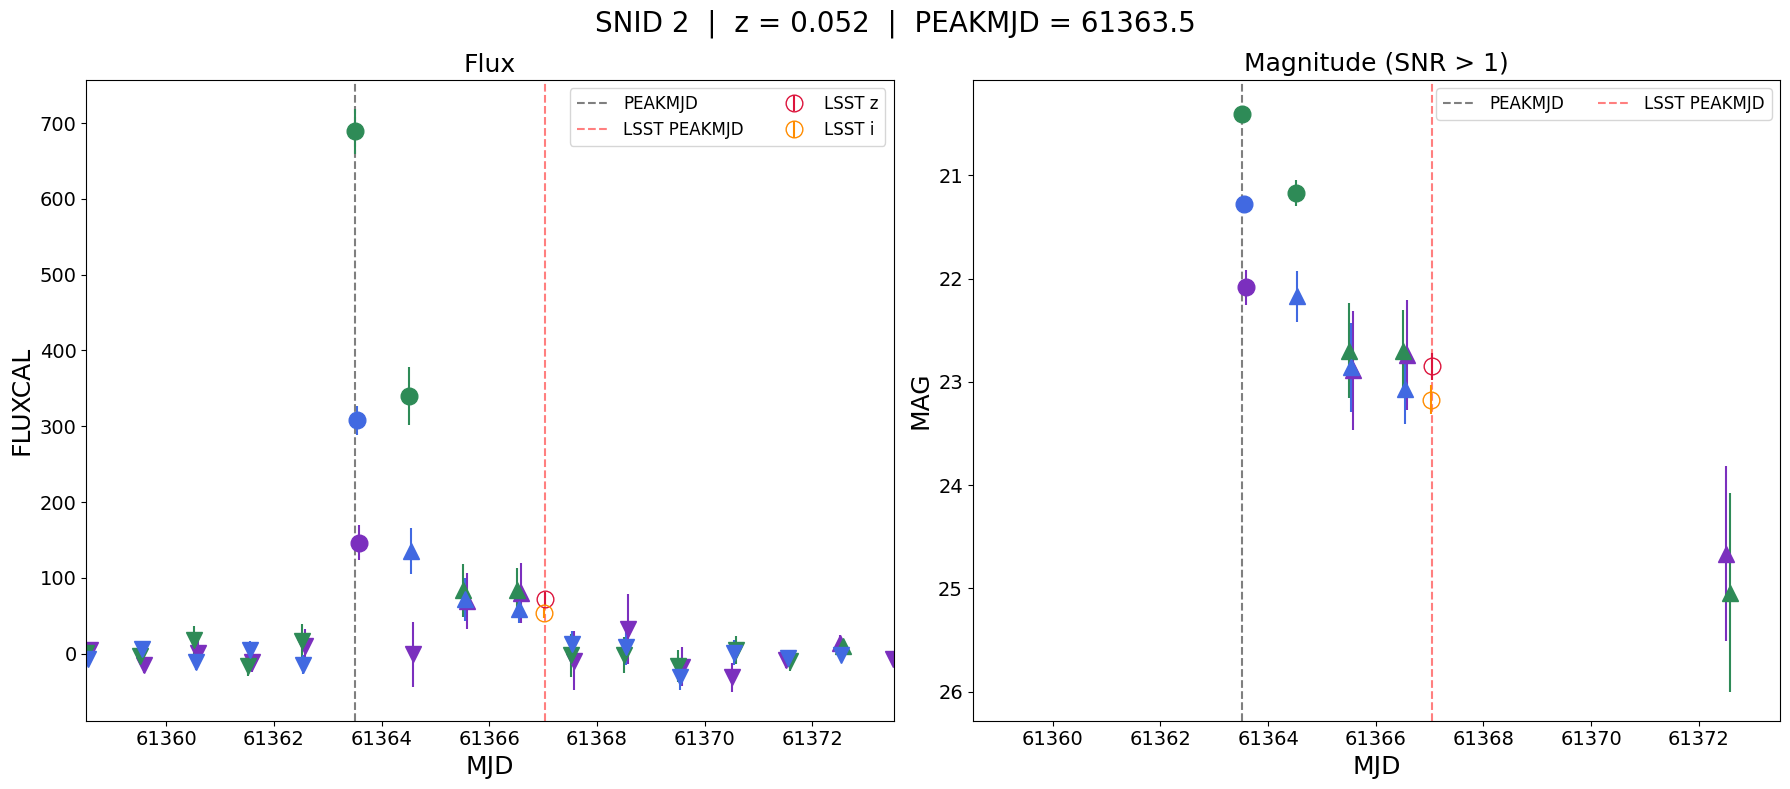

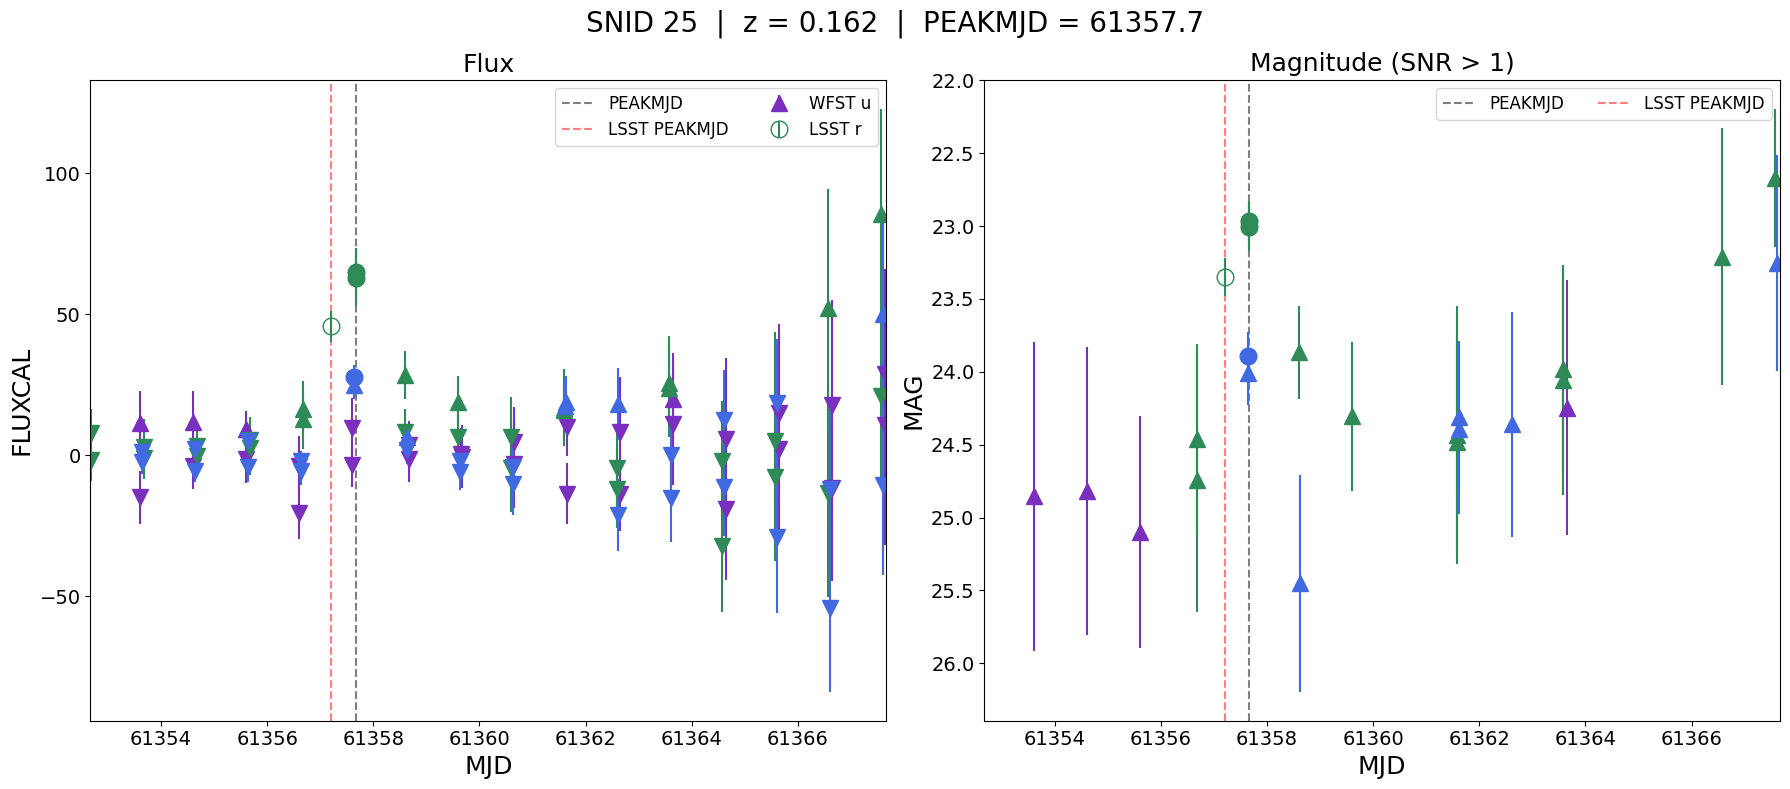

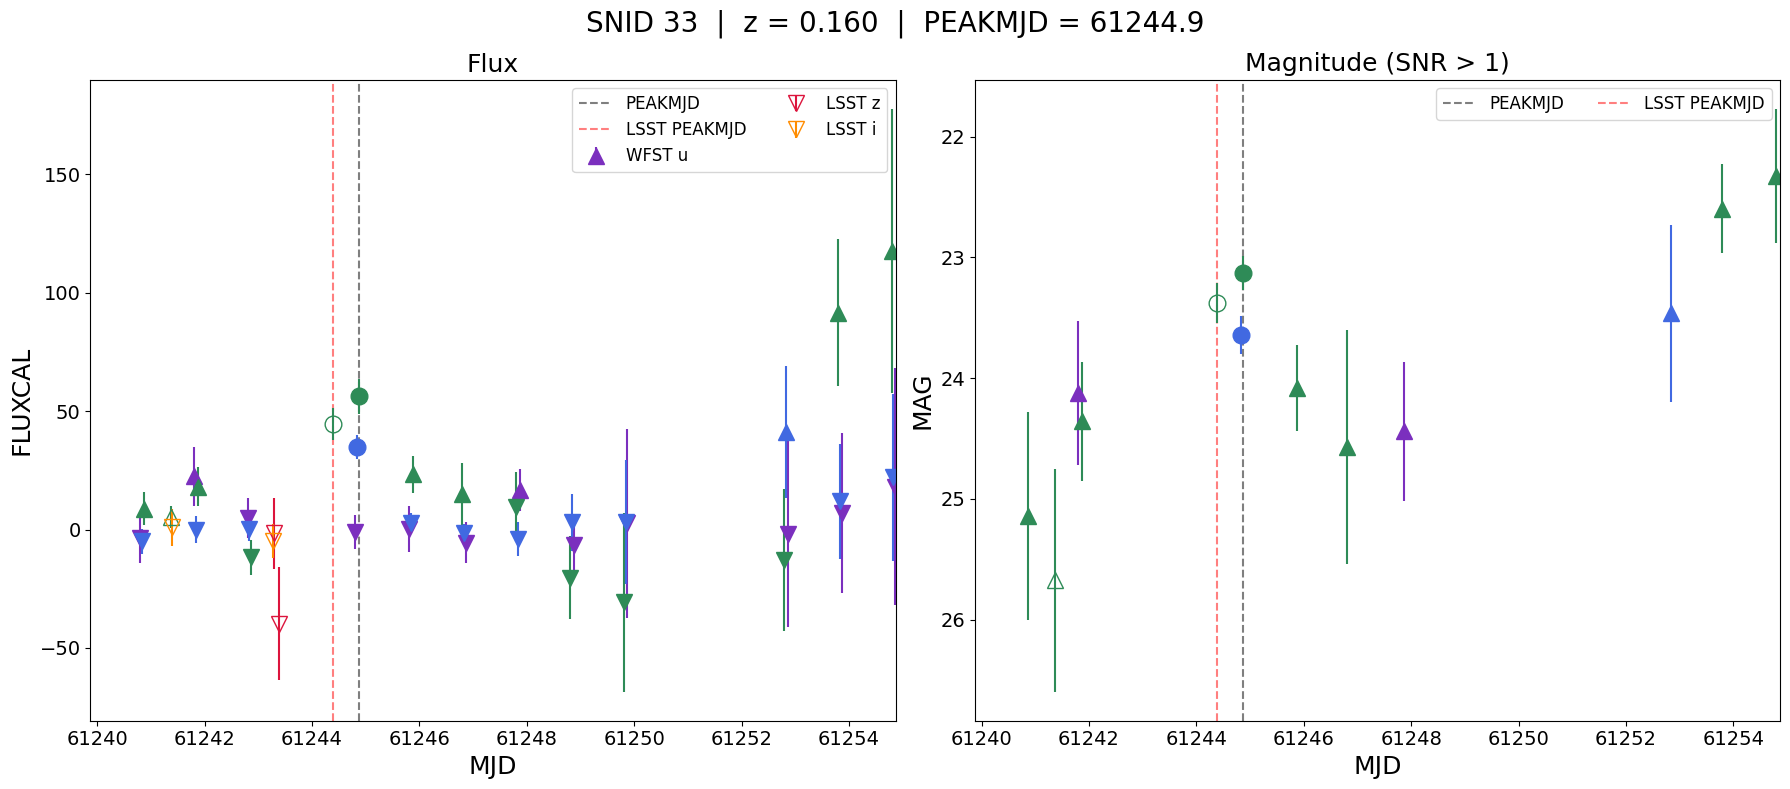

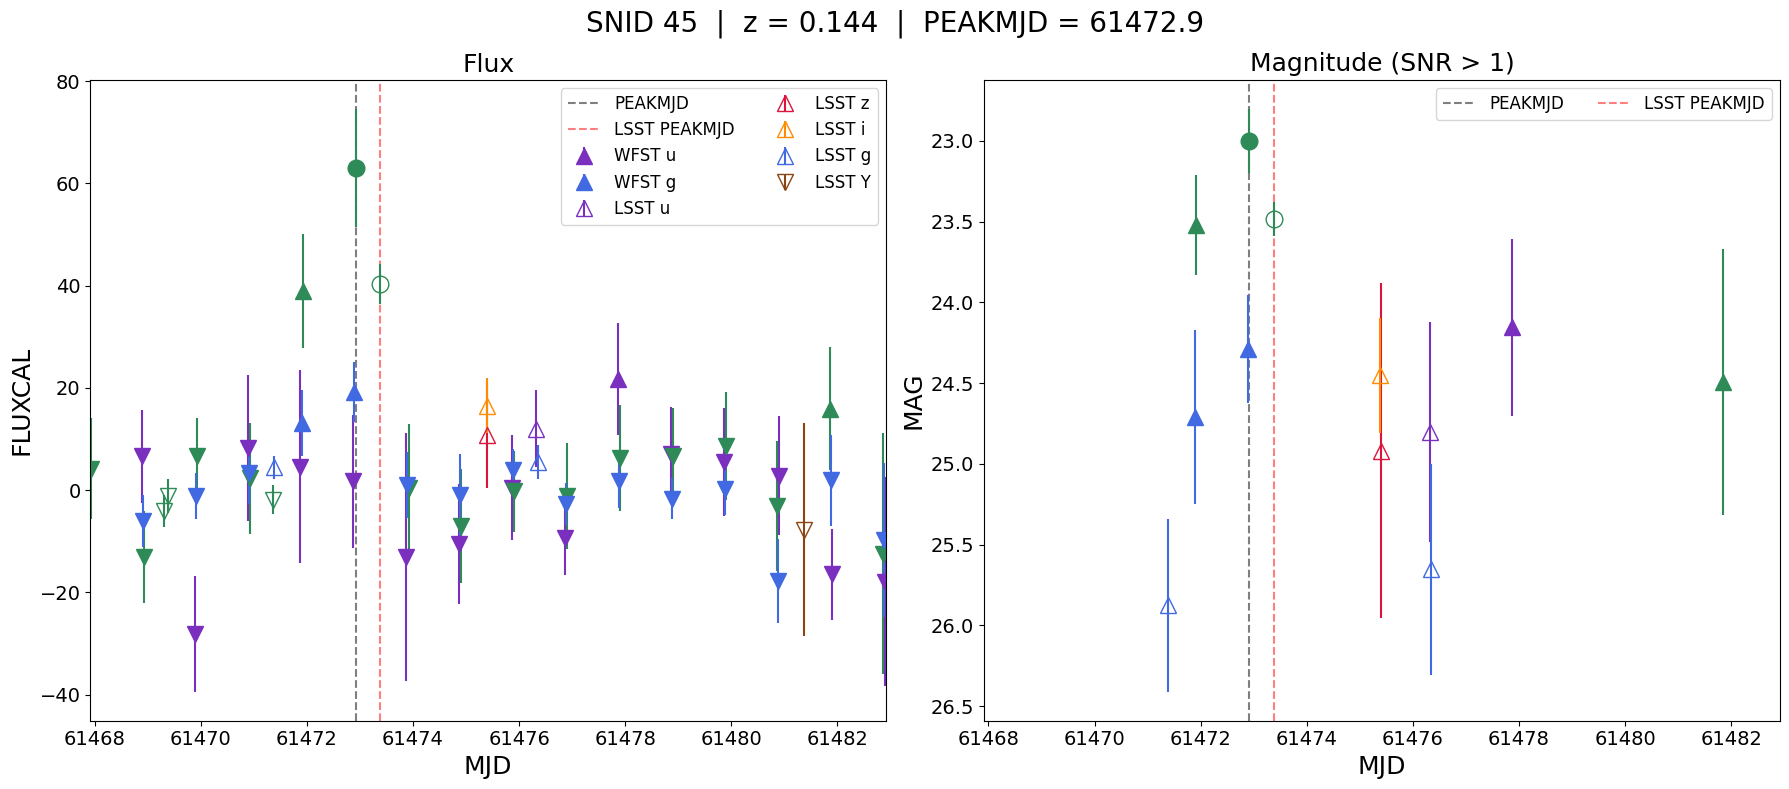

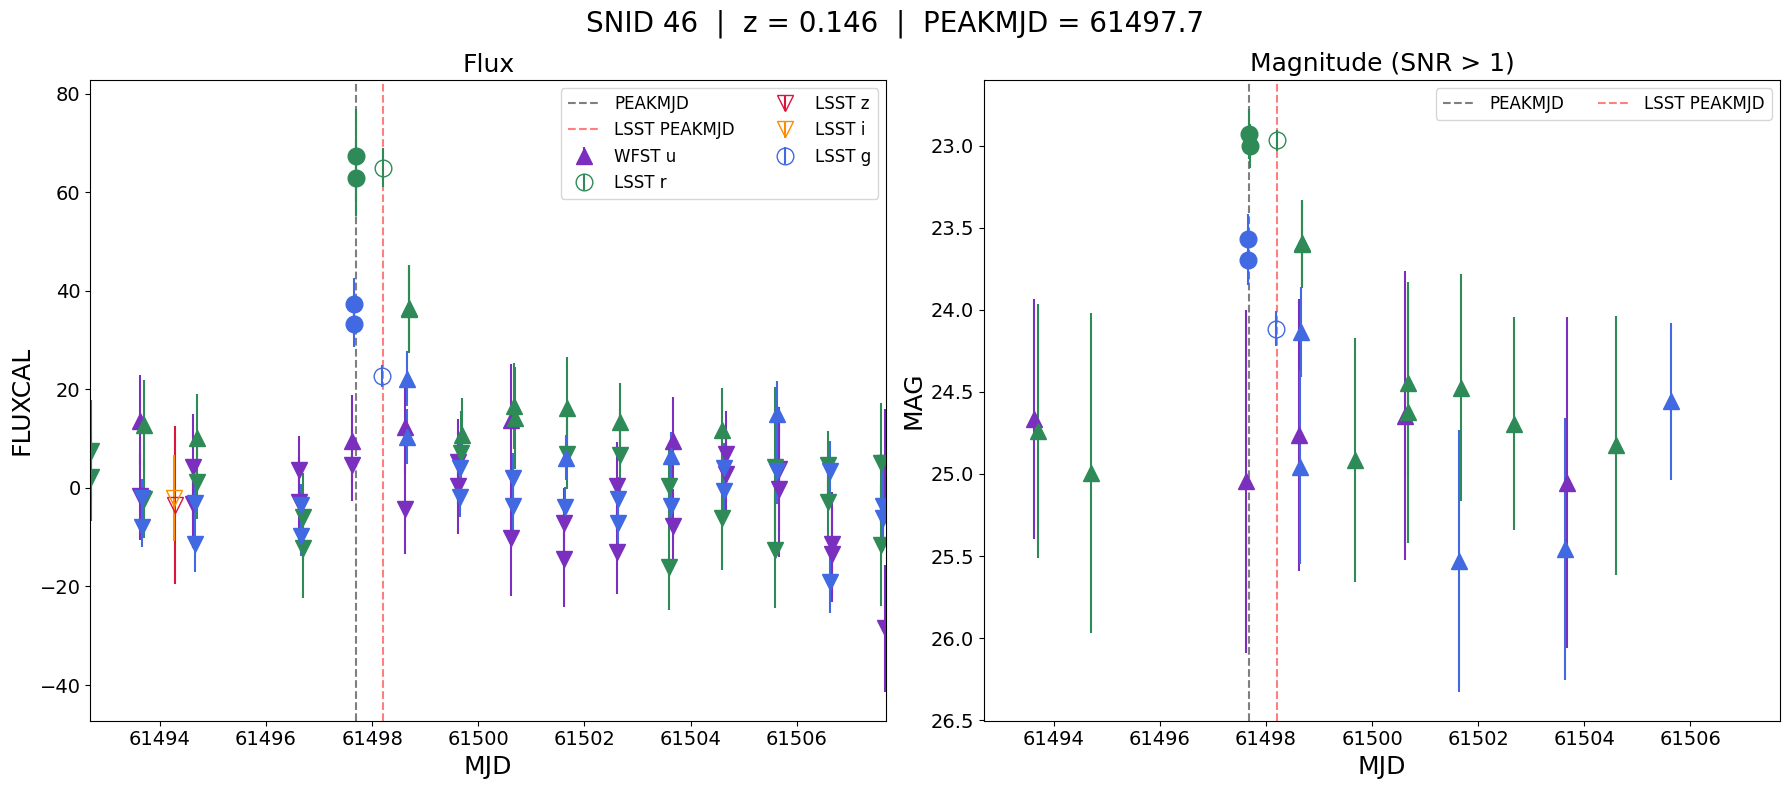

In [19]:
# Plot combined light curves for overlapping events
N_PLOT = min(5, len(overlap_snids))  # number of events to plot
T_MIN, T_MAX = -5, 10  # time range relative to PEAKMJD (days)

# Color map: WFST uses solid markers, LSST uses open markers
band_colors = {
    'u': '#7B2FBE', 'r': '#2E8B57', 'z': '#DC143C',
    'i': '#FF8C00', 'g': '#4169E1', 'Y': '#8B4513',
}

for n, snid in enumerate(overlap_snids[:N_PLOT]):
    w_row, w_start, w_end = wfst_idx[snid]
    l_row, l_start, l_end = lsst_idx[snid]

    peakmjd = wfst_head['PEAKMJD'][w_row]
    lsst_peakmjd = lsst_head['PEAKMJD'][l_row]
    z = wfst_head['REDSHIFT_HELIO'][w_row]

    w_obs = wfst_phot[w_start - 1 : w_end]
    l_obs = lsst_phot[l_start - 1 : l_end]

    # Time cut relative to PEAKMJD
    mjd_min = peakmjd + T_MIN
    mjd_max = peakmjd + T_MAX

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
    fig.suptitle(f'SNID {snid}  |  z = {z:.3f}  |  PEAKMJD = {peakmjd:.1f}', fontsize=20)

    # --- Flux panel ---
    ax1.axvline(x=peakmjd, color='k', ls='--', alpha=0.5, label='PEAKMJD')
    ax1.axvline(x=lsst_peakmjd, color='r', ls='--', alpha=0.5, label='LSST PEAKMJD')

    # WFST data
    for band_char, color in band_colors.items():
        bname = f'WFST-{band_char}'
        mask = np.array([b.strip() == bname for b in w_obs['BAND']])
        tmask = (w_obs['MJD'] >= mjd_min) & (w_obs['MJD'] <= mjd_max)
        sel = mask & tmask
        if sel.any():
            flux = w_obs['FLUXCAL'][sel].copy().astype(float)
            fluxerr = w_obs['FLUXCALERR'][sel]
            snr = flux / fluxerr
            
            # Separate by SNR ranges
            snr_high = snr > 5
            snr_mid = (snr > 1) & (snr <= 5)
            snr_low = snr <= 1
            
            # Plot SNR > 5 (filled circles)
            if snr_high.any():
                ax1.errorbar(w_obs['MJD'][sel][snr_high], flux[snr_high],
                            yerr=fluxerr[snr_high], fmt='o', color=color, ms=12, label=f'WFST {band_char}' if not (snr_mid.any() or snr_low.any()) else '')
            
            # Plot 1 < SNR <= 5 (upper triangle, filled)
            if snr_mid.any():
                ax1.errorbar(w_obs['MJD'][sel][snr_mid], flux[snr_mid],
                            yerr=fluxerr[snr_mid], fmt='^', color=color, ms=12, label=f'WFST {band_char}' if not snr_high.any() else '')
            
            # Plot SNR <= 1 (lower triangle, filled)
            if snr_low.any():
                ax1.errorbar(w_obs['MJD'][sel][snr_low], flux[snr_low],
                            yerr=fluxerr[snr_low], fmt='v', color=color, ms=12, label=f'WFST {band_char}' if not (snr_high.any() or snr_mid.any()) else '')

    # LSST data
    for band_char, color in band_colors.items():
        bname = f'LSST-{band_char}'
        mask = np.array([b.strip() == bname for b in l_obs['BAND']])
        tmask = (l_obs['MJD'] >= mjd_min) & (l_obs['MJD'] <= mjd_max)
        sel = mask & tmask
        if sel.any():
            flux = l_obs['FLUXCAL'][sel].copy().astype(float)
            fluxerr = l_obs['FLUXCALERR'][sel]
            snr = flux / fluxerr
            
            # Separate by SNR ranges
            snr_high = snr > 5
            snr_mid = (snr > 1) & (snr <= 5)
            snr_low = snr <= 1
            
            # Plot SNR > 5 (open circles)
            if snr_high.any():
                ax1.errorbar(l_obs['MJD'][sel][snr_high], flux[snr_high],
                            yerr=fluxerr[snr_high], fmt='o', mfc='none', color=color, ms=12, label=f'LSST {band_char}' if not (snr_mid.any() or snr_low.any()) else '')
            
            # Plot 1 < SNR <= 5 (upper triangle, open)
            if snr_mid.any():
                ax1.errorbar(l_obs['MJD'][sel][snr_mid], flux[snr_mid],
                            yerr=fluxerr[snr_mid], fmt='^', mfc='none', color=color, ms=12, label=f'LSST {band_char}' if not snr_high.any() else '')
            
            # Plot SNR <= 1 (lower triangle, open)
            if snr_low.any():
                ax1.errorbar(l_obs['MJD'][sel][snr_low], flux[snr_low],
                            yerr=fluxerr[snr_low], fmt='v', mfc='none', color=color, ms=12, label=f'LSST {band_char}' if not (snr_high.any() or snr_mid.any()) else '')

    ax1.set_xlim(mjd_min, mjd_max)
    ax1.set_xlabel('MJD', fontsize=18)
    ax1.set_ylabel('FLUXCAL', fontsize=18)
    ax1.tick_params(labelsize=14)
    ax1.legend(fontsize=12, ncol=2)
    ax1.set_title('Flux', fontsize=18)

    # --- Magnitude panel ---
    ax2.axvline(x=peakmjd, color='k', ls='--', alpha=0.5, label='PEAKMJD')
    ax2.axvline(x=lsst_peakmjd, color='r', ls='--', alpha=0.5, label='LSST PEAKMJD')

    for survey, obs, default_marker, default_mfc in [('WFST', w_obs, 'o', None), ('LSST', l_obs, 'o', 'none')]:
        for band_char, color in band_colors.items():
            bname = f'{survey}-{band_char}'
            mask = np.array([b.strip() == bname for b in obs['BAND']])
            tmask = (obs['MJD'] >= mjd_min) & (obs['MJD'] <= mjd_max)
            sel = mask & tmask
            if not sel.any():
                continue
            
            flux = obs['FLUXCAL'][sel].copy().astype(float)
            fluxerr = obs['FLUXCALERR'][sel]
            snr = flux / fluxerr
            mag, magerr = convert_fluxcal_to_mag(flux, fluxerr)
            
            # Separate by SNR ranges
            snr_high = snr > 5           # SNR > 5: circles
            snr_mid = (snr > 1) & (snr <= 5)  # 1 < SNR <= 5: upper triangle
            
            # Plot SNR > 5 (circles)
            if snr_high.any():
                kw = dict(fmt=default_marker, color=color, ms=12)
                if default_mfc:
                    kw['mfc'] = default_mfc
                ax2.errorbar(obs['MJD'][sel][snr_high], mag[snr_high], 
                            yerr=magerr[snr_high], **kw)
            
            # Plot 1 < SNR <= 5 (upper triangle)
            if snr_mid.any():
                marker_mid = '^'
                mfc_mid = None if survey == 'WFST' else 'none'
                kw = dict(fmt=marker_mid, color=color, ms=12)
                if mfc_mid:
                    kw['mfc'] = mfc_mid
                ax2.errorbar(obs['MJD'][sel][snr_mid], mag[snr_mid],
                            yerr=magerr[snr_mid], **kw)

    ax2.set_xlim(mjd_min, mjd_max)
    ax2.set_xlabel('MJD', fontsize=18)
    ax2.set_ylabel('MAG', fontsize=18)
    ax2.tick_params(labelsize=14)
    ax2.invert_yaxis()
    ax2.legend(fontsize=12, ncol=2)
    ax2.set_title('Magnitude (SNR > 1)', fontsize=18)

    plt.tight_layout()
    plt.show()